In [1]:
import sys
sys.path.append('../../../../')

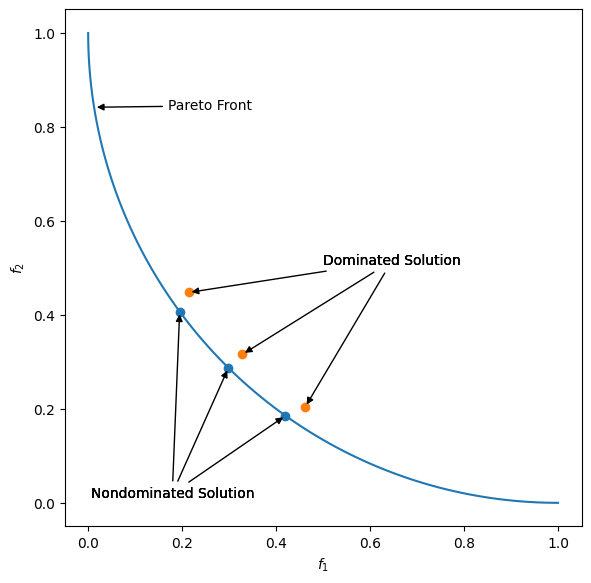

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Only plot third quadrant
theta = np.linspace(np.pi, 1.5*np.pi, 100)

# the radius of the circle
r = 1

# compute x1 and x2
x1 = r*np.cos(theta) + 1
x2 = r*np.sin(theta) + 1

# create the figure
fig, ax = plt.subplots(1, figsize=(6, 6))
ax.set_aspect(1)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")


# Plot and Annotate Pareto front
ax.plot(x1, x2)

i = 10
ax.annotate(
    'Pareto Front', xy=(x1[i], x2[i]),  xycoords='data',
    xytext=(0.2, 0.8), textcoords='axes fraction',
    arrowprops=dict(arrowstyle='-|>', facecolor='black'),
    horizontalalignment='left', verticalalignment='bottom',
)
# Plot and annotate non-dominated solutions
indices = [40, 50, 60]
nondominated = np.array([(x1[i], x2[i]) for i in indices])

ax.scatter(nondominated[:,0], nondominated[:,1])

for ind in nondominated:
    ax.annotate(
        'Nondominated Solution', xy=ind,  xycoords='data',
        xytext=(0.05, 0.05), textcoords='axes fraction',
        arrowprops=dict(arrowstyle='-|>', facecolor='black'),
        horizontalalignment='left', verticalalignment='bottom',
    )

# Plot and annotate dominated solutions
dominated = 1.1*nondominated

ax.scatter(dominated[:,0], dominated[:,1])

for ind in dominated:
    ax.annotate(
        'Dominated Solution', xy=ind,  xycoords='data',
        xytext=(0.5, 0.5), textcoords='axes fraction',
        arrowprops=dict(arrowstyle='-|>', facecolor='black'),
        horizontalalignment='left', verticalalignment='bottom',
    )

fig.tight_layout()

In [3]:
from CADETProcess.optimization import OptimizationProblem
optimization_problem = OptimizationProblem('meta_score_demo')
optimization_problem.add_variable('x', lb=0, ub=10)
optimization_problem.add_variable('y', lb=0, ub=10)

[INFO 08-12 16:19:01] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.52


RangedParameter(name='y', parameter_type=float, lb=0, ub=10)

In [4]:
import numpy as np

def objective_yield(x):
    return x[0]

def objective_purity(x):
    return x[1]

optimization_problem.add_objective(objective_yield)
optimization_problem.add_objective(objective_purity)

def overall_cost(x):
    return 0.7 * x[0] + 0.3 * x[1]

optimization_problem.add_meta_score(overall_cost)